In [6]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import cv2

In [ ]:
DATASET_PATH = "../data/archive"
NEGATIVE_PATH = os.path.join(DATASET_PATH, "Negative")
POSITIVE_PATH = os.path.join(DATASET_PATH, "Positive")

In [11]:

image_extensions = (".jpg", ".jpeg", ".png")

negative_images = [
    f for f in os.listdir(NEGATIVE_PATH)
    if f.lower().endswith(image_extensions)
]

positive_images = [
    f for f in os.listdir(POSITIVE_PATH)
    if f.lower().endswith(image_extensions)
]

negative_count = len(negative_images)
positive_count = len(positive_images)

df_dataset = pd.DataFrame({
    "Class": ["Negative", "Positive"],
    "Number of Images": [negative_count, positive_count]
})

df_dataset


,Class,Number of Images
0,Negative,20000
1,Positive,20000


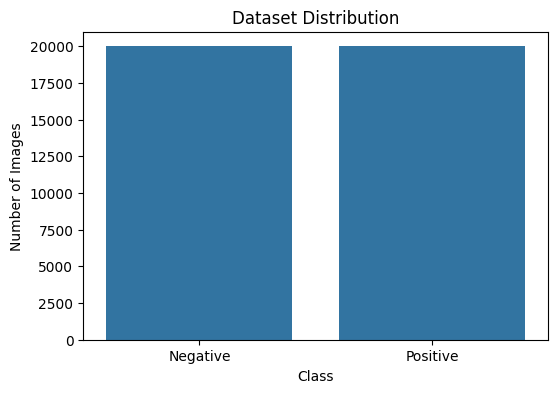

In [9]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=df_dataset,
    x="Class",
    y="Number of Images"
)

plt.title("Dataset Distribution")

plt.show()

In [ ]:
# This section aims to check that all images have the same dimensions (height, width, channels).

image_shapes = []
for file in os.listdir(NEGATIVE_PATH):
    if file.lower().endswith(image_extensions):
        img_path = os.path.join(NEGATIVE_PATH, file)
        img = cv2.imread(img_path)
        if img is not None:
            image_shapes.append({
                "Class": "Negative",
                "Height": img.shape[0],
                "Width": img.shape[1],
                "Channels": img.shape[2] if len(img.shape) == 3 else 1})

for file in os.listdir(POSITIVE_PATH):
    if file.lower().endswith(image_extensions):
        img_path = os.path.join(POSITIVE_PATH, file)
        img = cv2.imread(img_path)
        if img is not None:
            image_shapes.append({
                "Class": "Positive",
                "Height": img.shape[0],
                "Width": img.shape[1],
                "Channels": img.shape[2] if len(img.shape) == 3 else 1})

df_shapes = pd.DataFrame(image_shapes)
df_shapes.head()

,Class,Height,Width,Channels
0,Negative,227,227,3
1,Negative,227,227,3
2,Negative,227,227,3
3,Negative,227,227,3
4,Negative,227,227,3


In [15]:
df_shapes[["Height", "Width", "Channels"]].value_counts()

Height  Width  Channels
227     227    3           40000
Name: count, dtype: int64

In [17]:
# Check if all images have the same dimensions
unique_shapes = df_shapes[["Height", "Width", "Channels"]].drop_duplicates()
df_shapes.describe()

,Height,Width,Channels
count,40000.0,40000.0,40000.0
mean,227.0,227.0,3.0
std,0.0,0.0,0.0
min,227.0,227.0,3.0
25%,227.0,227.0,3.0
50%,227.0,227.0,3.0
75%,227.0,227.0,3.0
max,227.0,227.0,3.0


In [ ]:
def show_sample_images(folder_path, class_name, num_images=5):
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(image_extensions)]
    sample_images = image_files[:num_images]

    plt.figure(figsize=(15, 5))
    for i, img_file in enumerate(sample_images):
        img_path = os.path.join(folder_path, img_file)
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # plt.subplot(1, num_images, i + 1) means that we are creating a grid of subplots with 1 row and num_images columns, and we are currently plotting the (i + 1)-th image in that grid. The reason for using (i + 1) is that subplot indices start from 1, not 0.
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

    # plt.tight_layout()
    plt.show()

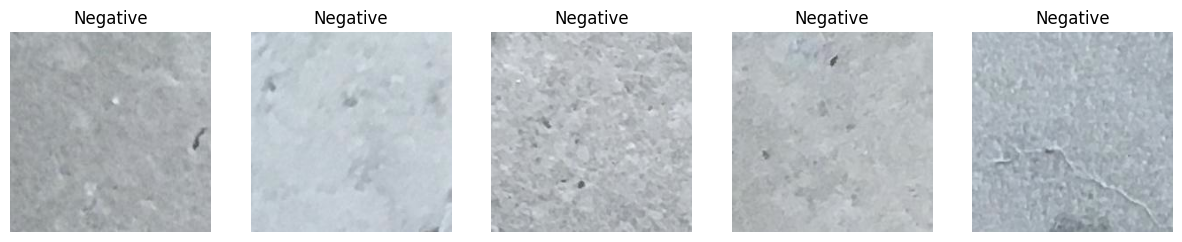

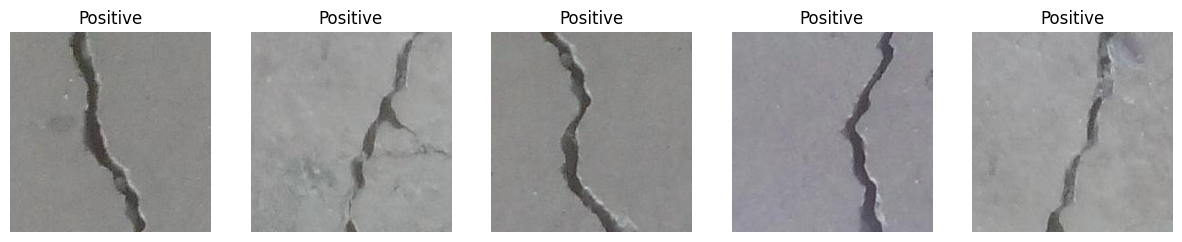

In [20]:
show_sample_images(NEGATIVE_PATH, "Negative")
show_sample_images(POSITIVE_PATH, "Positive")